In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# data_tvbs公路 = pd.read_csv('tvbs_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1177
# data_tvbs改 = pd.read_csv('tvbs_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #380
# data_自由公路 = pd.read_csv('自由_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #3959
# data_自由改 = pd.read_csv('自由_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #2598
data_ettoday公路 = pd.read_csv('ettoday_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1702
data_ettoday改 = pd.read_csv('ettoday_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1057
data_ettoday公路['PublishTime'] = pd.to_datetime(data_ettoday公路['PublishTime'], errors='coerce')
data_ettoday公路['PublishTime'] = data_ettoday公路['PublishTime'].dt.strftime('%Y/%m/%d %H:%M')
data_ettoday改['PublishTime'] = pd.to_datetime(data_ettoday改['PublishTime'], errors='coerce')
data_ettoday改['PublishTime'] = data_ettoday改['PublishTime'].dt.strftime('%Y/%m/%d %H:%M')
# data = pd.concat([data_tvbs公路, data_tvbs改, data_自由公路, data_自由改, data_ettoday公路, data_ettoday改], ignore_index=True)
data = pd.concat([data_ettoday公路, data_ettoday改], ignore_index=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        2704 non-null   object
 1   Context      2704 non-null   object
 2   PublishTime  2656 non-null   object
dtypes: object(3)
memory usage: 63.5+ KB


In [58]:
data['Context'].duplicated().sum()

277

In [59]:
data = data[~data['Context'].duplicated()].reset_index(drop=True)

In [60]:
data.head(10)

,Title,Context,PublishTime
0,花蓮台9線車禍！雙載機車自撞「跌落邊坡20m」 消防救援畫面曝,蘇花公路台9線161公里處，今（22）日早上發生交通事故，雙載機車不明原因自撞，摔落邊坡約2...,2025/06/22 10:33
1,花公路落石釀車損！1輛引擎蓋凹陷、1輛左前輪爆胎,蘇花公路宜蘭南澳鄉台九線116公里處發生落石擊中車輛事故。15日下午13時許，一輛轎車引擎蓋...,2025/06/16 14:57
2,花蓮對面是阿根廷福爾摩沙省 他們以藝術紀錄地震傷痕,花蓮地震寫生團像一支自動發起的遠征隊，由一群在地年輕藝術家組成，在2024年4月3日的花蓮震...,2025/06/09 11:47
3,11萬噸殘骸的土資場沒錢處理 脆弱交通讓花蓮旅遊雪上加霜,東華大學化學實驗室在震後因化學物品翻覆起火，燒了整整22個小時。寫生團進入實驗室內部時，現場...,2025/06/09 11:46
4,蘇花公路和仁路段管制閘門施工 6月9至13日機動交管,台九線蘇花公路和仁路段將進行管制閘門施工，自6月9日至6月13日每日上午8時至下午5時，實施...,2025/06/05 14:07
5,快訊／豪雨、土石流強襲花蓮縣 秀林鄉和平村明上午停班停課,受到20日豪大雨影響，花蓮多地傳出淹水、土石流等災情。對此，花蓮縣秀林鄉公所18日深夜緊急發...,2025/05/20 22:34
6,花蓮豪雨「土石流轟炸道路」恐怖畫面曝光 民眾躲隧道內尖叫,受豪雨影響，台9線蘇花公路164k處發生土石流，目前雙向交通中斷受阻，交通部已下令啟動海陸空...,2025/05/20 20:46
7,花蓮爆雨「蘇花鐵公路雙斷」 交長下令啟動海陸空跨運具聯防,今(20)日16時起花蓮地區因豪雨不斷，蘇花公路台9線162.9公里處落石瀑、164.4公里...,2025/05/20 20:24
8,蘇花路廊土石流阻斷「80車受困」 今晚9時搶通,台9線蘇花路廊和仁到崇德路段上邊坡土石流狂瀉，導致阻斷無法通行，南下72部、北上7部共80輛...,2025/05/20 19:12
9,蘇花公路又中斷！土石流狂瀉 和仁到崇德段只出不進,大雨不斷，台9線蘇花公路164k處發生土石流，目前雙向交通中斷受阻。公路局宣布，今下午4時半...,2025/05/20 16:53


In [61]:
data['PublishTime'] = pd.to_datetime(data['PublishTime'], format='%Y/%m/%d %H:%M', errors='coerce')

In [62]:
data['PublishYear'] = data['PublishTime'].dt.to_period('Y').astype(str)

In [63]:
data

,Title,Context,PublishTime,PublishYear
0,花蓮台9線車禍！雙載機車自撞「跌落邊坡20m」 消防救援畫面曝,蘇花公路台9線161公里處，今（22）日早上發生交通事故，雙載機車不明原因自撞，摔落邊坡約2...,2025-06-22 10:33:00,2025
1,花公路落石釀車損！1輛引擎蓋凹陷、1輛左前輪爆胎,蘇花公路宜蘭南澳鄉台九線116公里處發生落石擊中車輛事故。15日下午13時許，一輛轎車引擎蓋...,2025-06-16 14:57:00,2025
2,花蓮對面是阿根廷福爾摩沙省 他們以藝術紀錄地震傷痕,花蓮地震寫生團像一支自動發起的遠征隊，由一群在地年輕藝術家組成，在2024年4月3日的花蓮震...,2025-06-09 11:47:00,2025
3,11萬噸殘骸的土資場沒錢處理 脆弱交通讓花蓮旅遊雪上加霜,東華大學化學實驗室在震後因化學物品翻覆起火，燒了整整22個小時。寫生團進入實驗室內部時，現場...,2025-06-09 11:46:00,2025
4,蘇花公路和仁路段管制閘門施工 6月9至13日機動交管,台九線蘇花公路和仁路段將進行管制閘門施工，自6月9日至6月13日每日上午8時至下午5時，實施...,2025-06-05 14:07:00,2025
...,...,...,...,...
2422,馬：對不起東部居民 應加速南迴鐵路電氣化,馬英九總統8日在國民黨中常會指出，台灣要邁向千萬觀光大國，提升品質是當務之急，政府推動觀光發...,2012-08-09 12:53:00,2012
2423,宜縣長視察南澳 預防蘇花改通車破壞原住民文化,我們想讓你知道…保存原住民文化很重要!\n\n2015年蘇花改通車以後，位在宜蘭縣的南澳鄉將...,2012-04-20 21:17:00,2012
2424,馬英九花蓮掃街固盤 允諾太魯閣號增班,我們想讓你知道…蔡前腳走，馬跟進掃花蓮，擺明就是固盤啦\n\n馬英九總統3日展開花東地區掃街...,2012-01-03 18:47:00,2012
2425,馬英九：十年內加入TPP,我們想讓你知道…國、民兩黨都開始打TPP牌了。\n\n總統馬英九22日表示，政府已創造有利於...,2011-11-22 21:33:00,2011


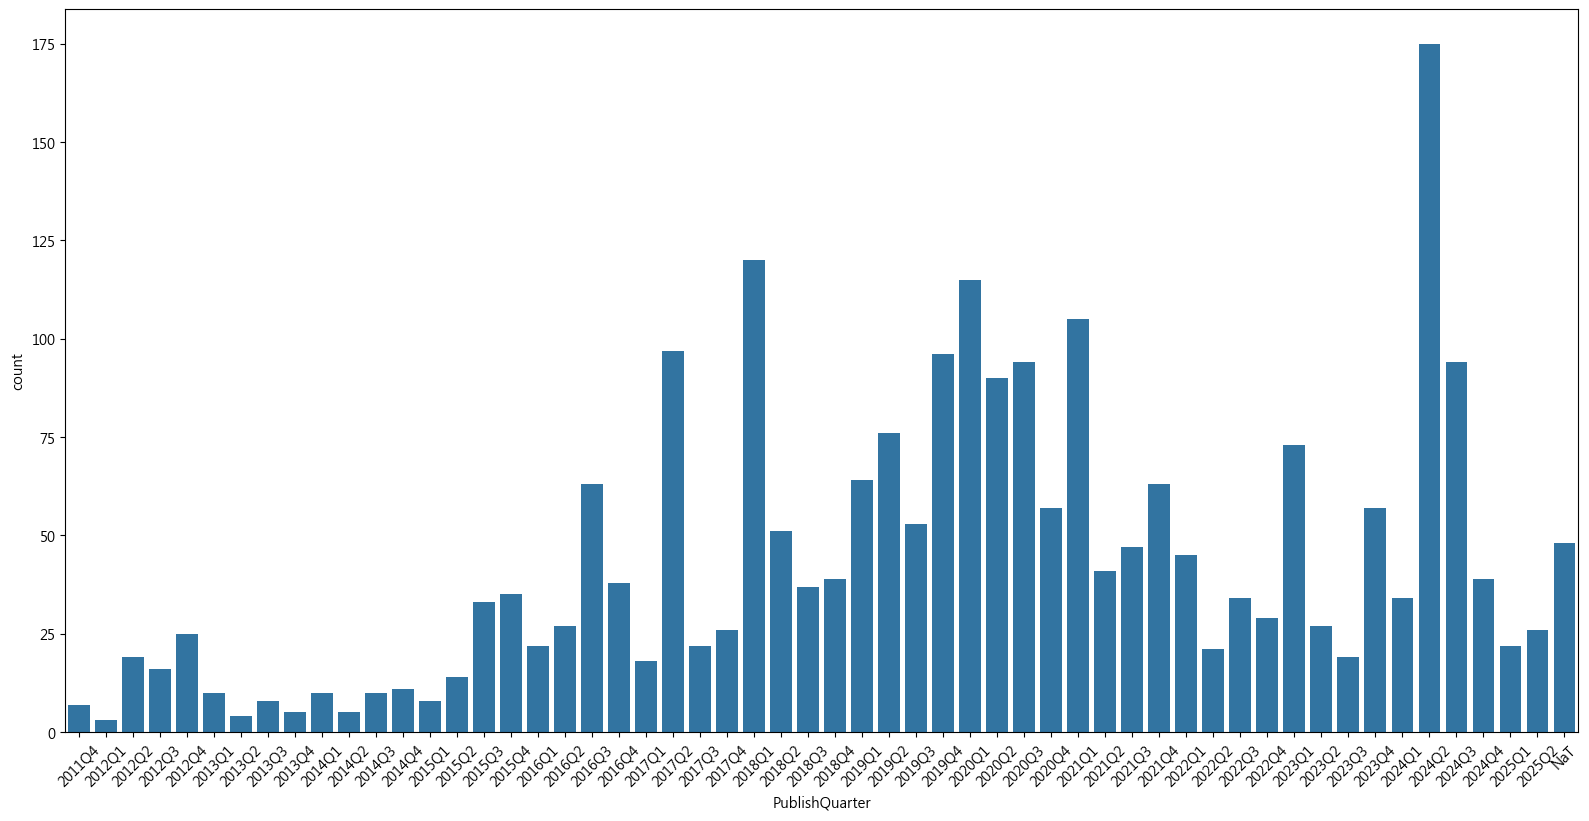

In [64]:
data['PublishQuarter'] = data['PublishTime'].dt.to_period('Q').astype(str)
plt.figure(figsize=(16, 8))
sns.countplot(data=data, x='PublishQuarter', order=sorted(data['PublishQuarter']))
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [65]:
data = data[(pd.to_datetime(data['PublishTime']) >= pd.Timestamp('2015-01-01')) 
            & (pd.to_datetime(data['PublishTime']) <= pd.Timestamp('2024-12-31'))].reset_index(drop=True)


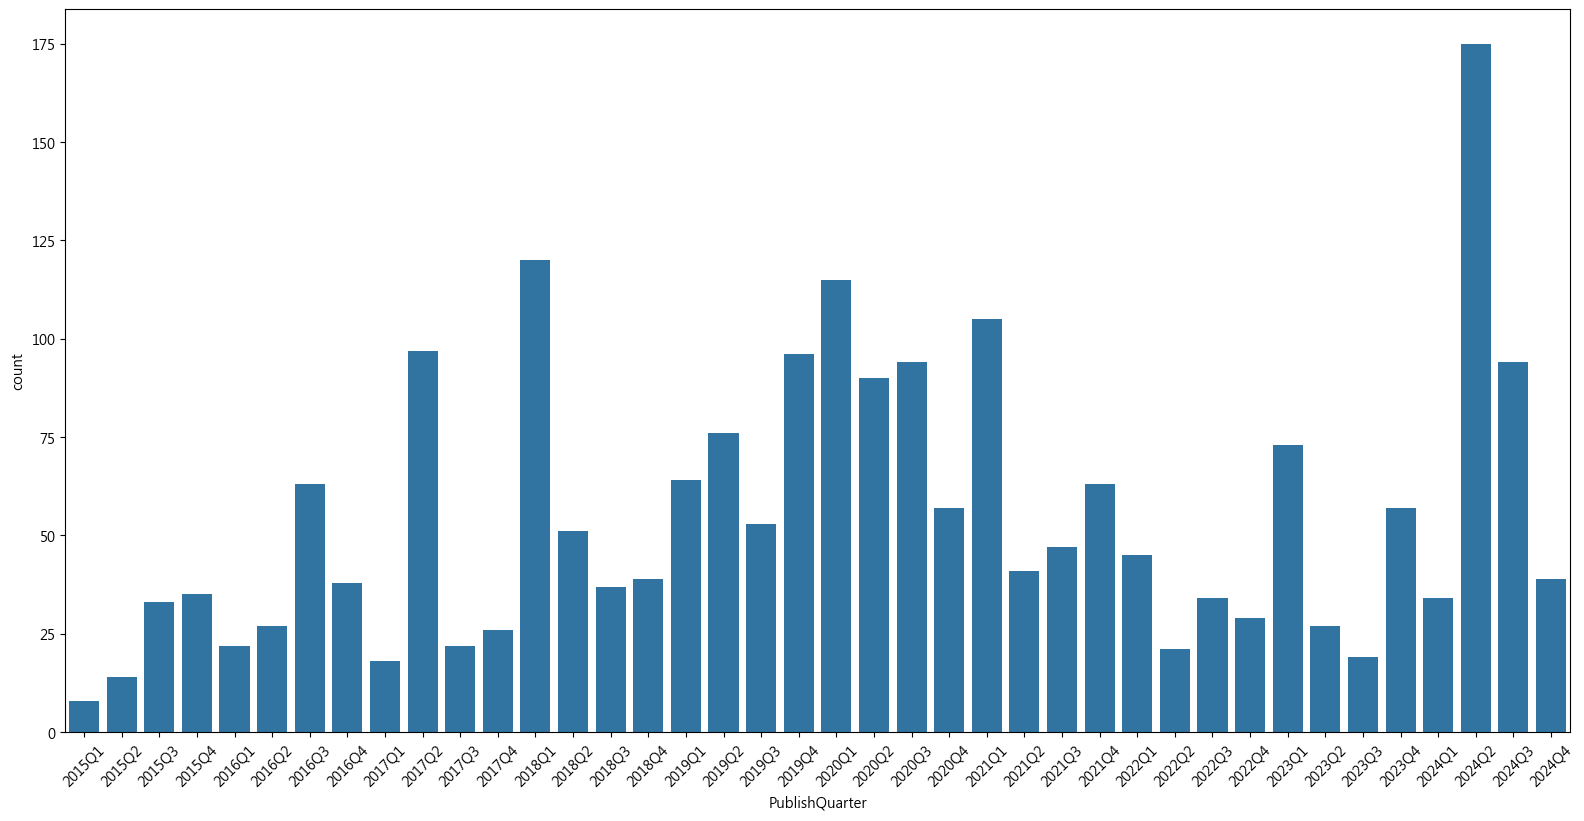

In [66]:
plt.figure(figsize=(16, 8))
sns.countplot(data=data, x='PublishQuarter', order=sorted(data['PublishQuarter']))
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [67]:
text_all = '\n'.join(data['Context'].dropna())

In [68]:
import jieba, re, string

In [69]:
fullwidth_punctuation = "，。！？：；「」『』（）〔〕【】《》—…～‧、．／"
all_punct = string.punctuation + fullwidth_punctuation
def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    
    # 刪除「首次上稿 時間 更新時間 時間」格式（容許冒號遺失）
    text = re.sub(r'首次上稿\s?\d{0,2}[:：]?\d{0,2}?\s*更新時間\s?\d{0,2}[:：]?\d{0,2}', '', text)
    text = re.sub(r'首次上稿\s*', '', text)
    text = re.sub(r'更新時間\s*', '', text)

    # 刪除「〔記者XXX／XXX報導〕」格式
    text = re.sub(r'〔記者.{1,10}／.{1,10}報導〕', '', text)

    # 移除「記者XXX／XXX報導」無括號變形
    text = re.sub(r'記者.{1,10}[／／]{1}.{1,10}報導', '', text)

    text = text.translate(str.maketrans('', '', all_punct))  # 刪標點
    text = re.sub(r'\[.*?\]', '', text) # 刪 [] 內內容
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # 刪網址
    text = re.sub(r'<.*?>+', '', text) # 刪 HTML tag
    text = re.sub(r'\n', ' ', text) # 換行→空白
    # text = re.sub(r'\w*\d\w*', ' ', text) # 含數字詞
    text = re.sub(r'\d+', ' ', text) # 數字
    text = re.sub(r'\s+', ' ', text).strip() # 連續空白
    return text
data["Cleaned_Context"] = data["Context"].apply(clean_text)
data.head(10)

,Title,Context,PublishTime,PublishYear,PublishQuarter,Cleaned_Context
0,回顧2024年「全台10大熱門旅遊話題」 赴泰免簽、403地震都上榜,2024年即將步入尾聲，《ETtoday新聞雲》回顧過去一年，整理出台灣10大熱門旅遊話題，...,2024-12-29 16:29:00,2024,2024Q4,年即將步入尾聲ettoday新聞雲回顧過去一年整理出台灣 大熱門旅遊話題包括地震對花蓮觀光影...
1,羅東夜市美食攻略地圖！收錄12家「不踩雷小吃攤」一網打盡,集合愛吃、愛玩、愛旅行的朋友!\n親子旅行說走就走~\n來到宜蘭旅遊必逛的行程就是我最愛的羅...,2024-12-28 16:24:00,2024,2024Q4,集合愛吃愛玩愛旅行的朋友 親子旅行說走就走 來到宜蘭旅遊必逛的行程就是我最愛的羅東夜市啦這次...
2,蘇花下清水橋臨時便橋拆除 12／11~20全天單線雙向交通管制,蘇花公路下清水橋臨時便橋將進行拆除施工，施工期間全天進行單線雙向交通號誌管制。\n東區養護工...,2024-12-11 13:14:00,2024,2024Q4,蘇花公路下清水橋臨時便橋將進行拆除施工施工期間全天進行單線雙向交通號誌管制 東區養護工程分局...
3,陳世凱上任百日挑戰「從非交通出身到有感拆彈」 好感度奪第1,交通部前部長李孟諺爆婚外情請辭，陳世凱臨危受命接棒，曾被質疑非交通專業出身的陳世凱，任職滿1...,2024-12-08 09:39:00,2024,2024Q4,交通部前部長李孟諺爆婚外情請辭陳世凱臨危受命接棒曾被質疑非交通專業出身的陳世凱任職滿 天不但...
4,山巒起伏、漁港之美盡收眼底！南方澳觀景台「追日出」最佳理想地,Ben & Jean 的美好生活小旅行...美食/旅遊/親子/生活日記\n<<旅行的樂趣-在...,2024-12-03 15:00:00,2024,2024Q4,ben jean 的美好生活小旅行美食旅遊親子生活日記 旅行的樂趣在於用味蕾記錄回憶 位於蘇...
5,蘇花改中仁隧道南向施工！11／30~12／31封閉 改走台九丁,台9線蘇花改中仁隧道南下隧道自11月30日17時起進行路基排水改善、地下管涵推進及路面與標線...,2024-11-26 13:02:00,2024,2024Q4,台 線蘇花改中仁隧道南下隧道自 月 日 時起進行路基排水改善地下管涵推進及路面與標線施工實工...
6,天兔颱風進逼「首波6公路警戒」 不排除預警封路,天兔颱風進逼，氣象署今(14日)晨已發布海警。公路局表示，目前已提升警戒作業嚴陣以待，首波可...,2024-11-14 09:34:00,2024,2024Q4,天兔颱風進逼氣象署今 日晨已發布海警公路局表示目前已提升警戒作業嚴陣以待首波可能預警封路公路...
7,保障花蓮鐵公路交通 石公溪疏濬規劃清出13.6萬立方土石,花蓮縣政府民政處7日於秀林鄉匯德隧道舉辦石公溪疏濬工程規劃設計協調會，縣長徐榛蔚在民政處長明...,2024-11-08 09:36:00,2024,2024Q4,花蓮縣政府民政處 日於秀林鄉匯德隧道舉辦石公溪疏濬工程規劃設計協調會縣長徐榛蔚在民政處長明良...
8,蘇花海運備援明午啟動 今下午14時起開放登記,康芮颱風影響，蘇花公路崇德路段164.4k因強降雨發生土石泥流，蘇花鐵公路皆中斷，航港局啟動...,2024-11-01 12:24:00,2024,2024Q4,康芮颱風影響蘇花公路崇德路段 k因強降雨發生土石泥流蘇花鐵公路皆中斷航港局啟動海運備援作業緊...
9,台鐵恢復行車大誤點 陳世凱：地震致花東線受損「下午3時搶通」,康芮颱風重創台鐵，花蓮崇德到和仁路線因土石流中斷，其他路線原規劃今日恢復行駛，不過一早北迴線...,2024-11-01 09:04:00,2024,2024Q4,康芮颱風重創台鐵花蓮崇德到和仁路線因土石流中斷其他路線原規劃今日恢復行駛不過一早北迴線花東線...


In [70]:
synonym_dict = {'花蓮縣':'花蓮', '花蓮市':'花蓮', '舊蘇花':'蘇花公路', '蘇花':'蘇花公路',
                '蘇花改':'蘇花改', '蘇花高':'蘇花高', '蘇花安':'蘇花安', '台九':'台九線', '台九丁線':'台九線'}
with open('停用詞-繁體中文.txt', encoding='utf-8') as f:
    stopwords = set(line.strip() for line in f)

In [71]:
from ckiptagger import WS
ws = WS("../data")

# text = ["蘇花改是蘇花公路的重要替代路段"]
# ws_results = ws(text)
# print(ws_results[0])

texts = data['Cleaned_Context'].fillna('').tolist()
ws_results = ws(texts)

data['CKIP_Tokens'] = ws_results

def normalize_ckip_tokens(tokens, synonym_dict, stopwords):
    normalize_tokens = [synonym_dict.get(token, token) for token in tokens]
    filter_tokens = [token for token in normalize_tokens if token not in stopwords and len(token)>1 and token.isalpha()]
    return filter_tokens

data['CKIP_Tokens'] = data['CKIP_Tokens'].apply(lambda x: normalize_ckip_tokens(x, synonym_dict, stopwords))


c:\Users\No\anaconda3\envs\RunCKIP\lib\site-packages\ckiptagger\model_ws.py:106: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)


In [74]:
del ws

In [ ]:
extra_words = ['新聞雲', '清水橋', '強降雨', '降雨', '土石流', '颱風', '重創']

for word in set(list(synonym_dict.keys()) + list(synonym_dict.values()) + extra_words):
    jieba.add_word(word)

def tokenize(text, synonym_dict, stopwords):
    if pd.isna(text):
        return []
    tokens = list(jieba.cut(text))
    normalize_tokens = [synonym_dict.get(token, token) for token in tokens]
    filter_tokens = [token for token in normalize_tokens if token not in stopwords and len(token)>1 and token.isalpha()]
    return filter_tokens

data['Tokens'] = data['Cleaned_Context'].apply(lambda x: tokenize(x, synonym_dict, stopwords))

# print(list(jieba.cut("蘇花改是蘇花公路的重要替代路段")))


In [76]:
from collections import Counter
all_tokens = [token for tokens in data['CKIP_Tokens'] for token in tokens]
word_freq = Counter(all_tokens)
top_tf = word_freq.most_common(30)

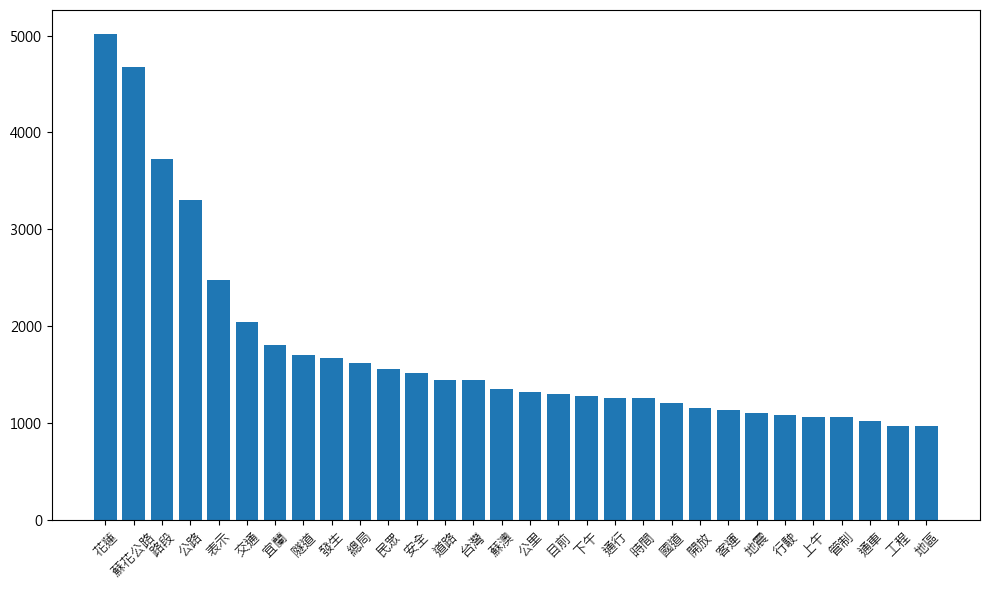

In [77]:
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
words, freqs = zip(*top_tf)
plt.figure(figsize=(10, 6))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
data['Joined_Tokens'] = data['CKIP_Tokens'].apply(lambda x: ' '.join(x))
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(data['Joined_Tokens'])
feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)


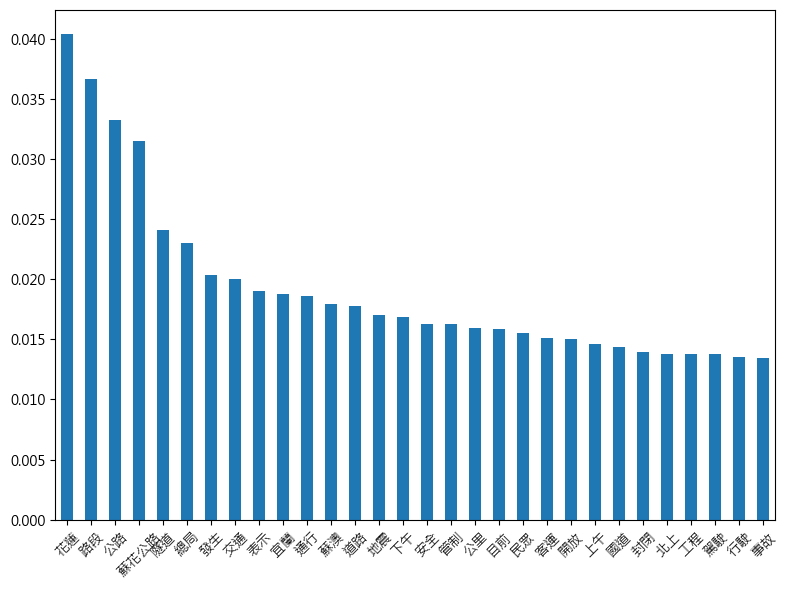

In [80]:
mean_tfidf = tfidf_df.mean().sort_values(ascending=False)
top_tfidf = mean_tfidf.head(30)
top_tfidf.plot(kind='bar', figsize=(8, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [81]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

In [82]:
vectorizer = CountVectorizer()
count_matrix = vectorizer.fit_transform(data['Joined_Tokens'])
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda_matrix = lda.fit_transform(count_matrix)

data['Topic'] = lda_matrix.argmax(axis=1) +1

In [83]:
topic_word =lda.components_
topic_word_prob = topic_word/topic_word.sum(axis=1)[:, np.newaxis]
tokens = vectorizer.get_feature_names_out()
phi_df = pd.DataFrame(topic_word_prob, columns=tokens, index=[f'Topic {i+1}' for i in range(lda.n_components)])

In [84]:
def plot_topic_token_distri(phi_df, top_n):
    for topic in phi_df.index:
        top_words = phi_df.loc[topic].sort_values(ascending=False).head(top_n)
        
        plt.figure(figsize=(8, 6))
        plt.bar(top_words.index, top_words.values)
        plt.title(f'{topic}-Top {top_n} Tokens')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

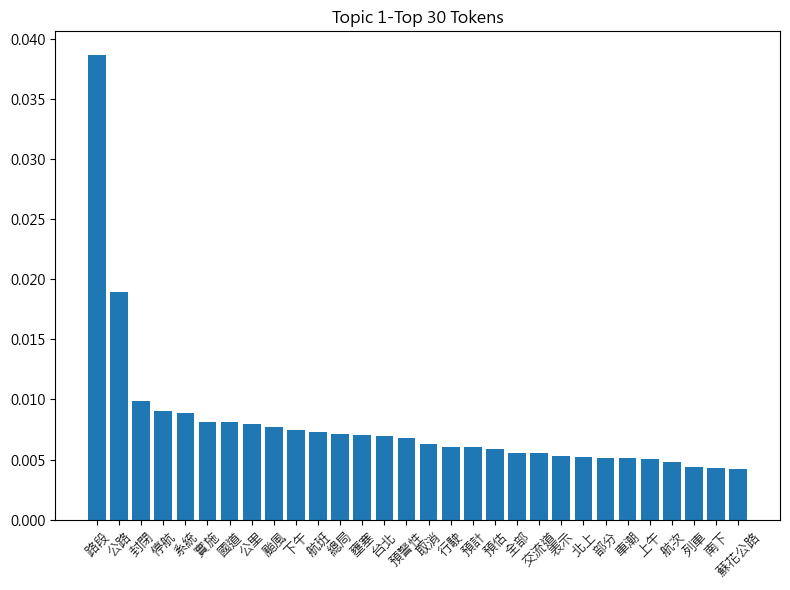

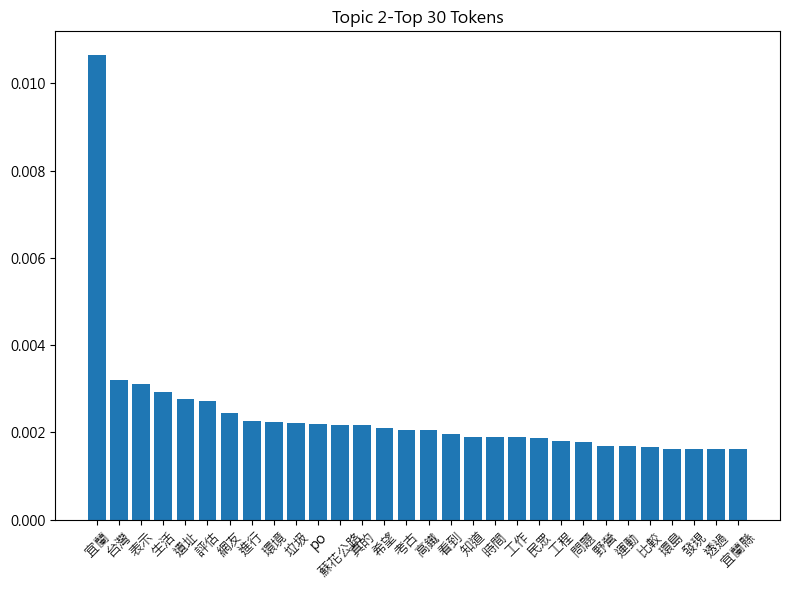

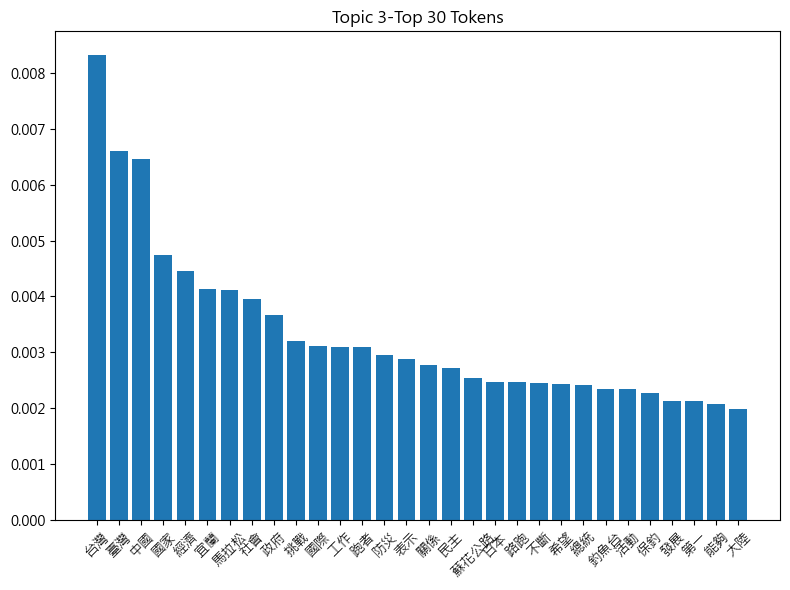

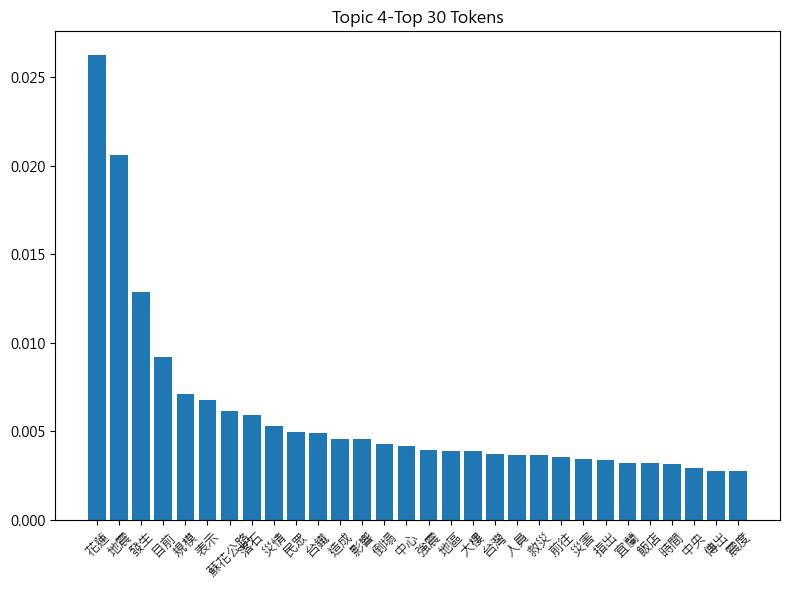

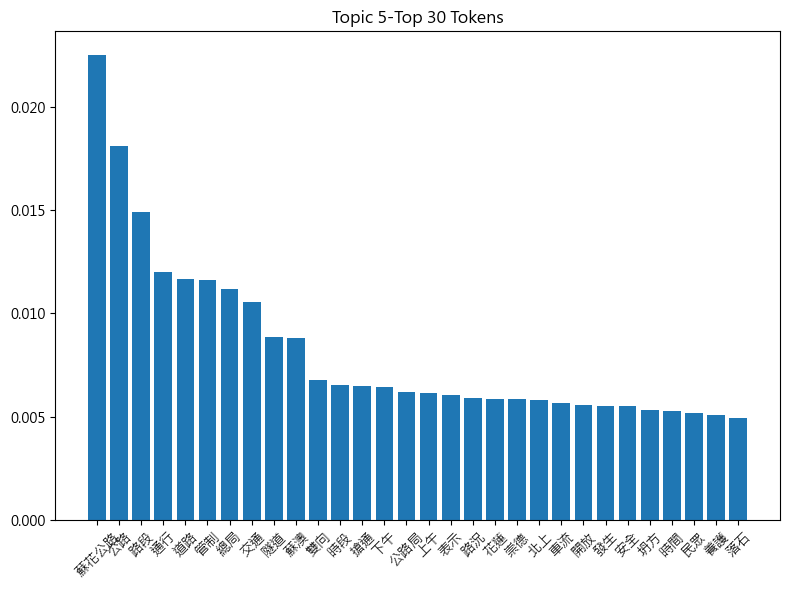

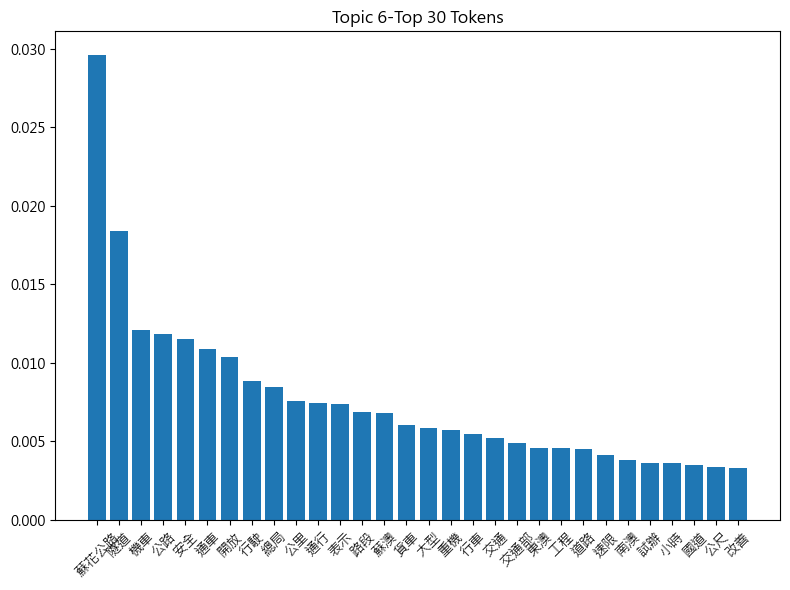

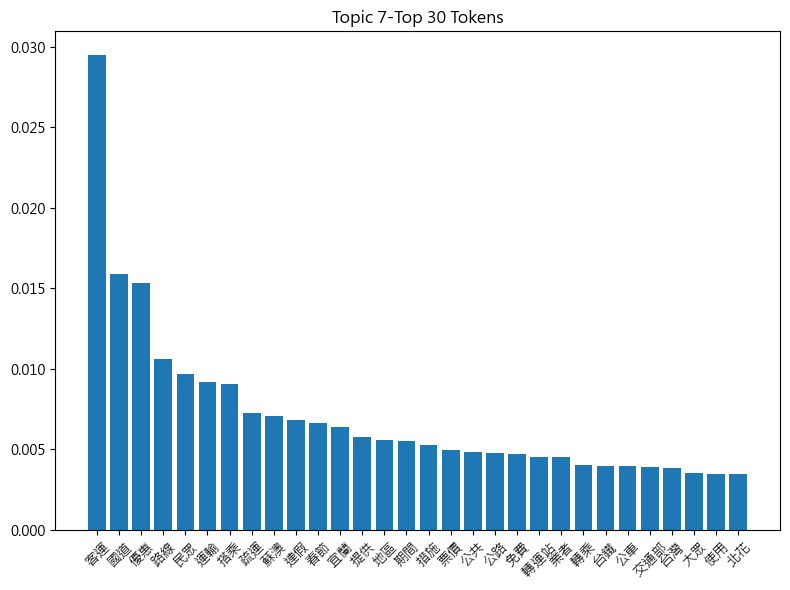

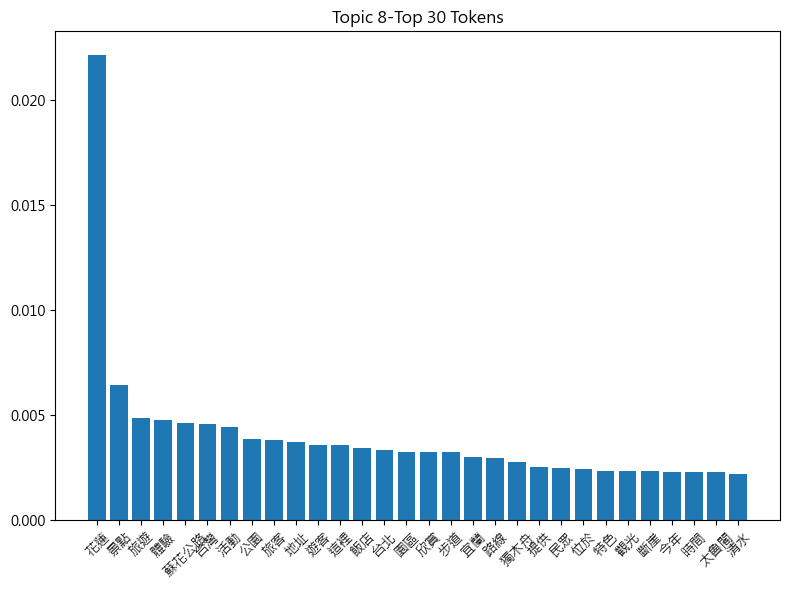

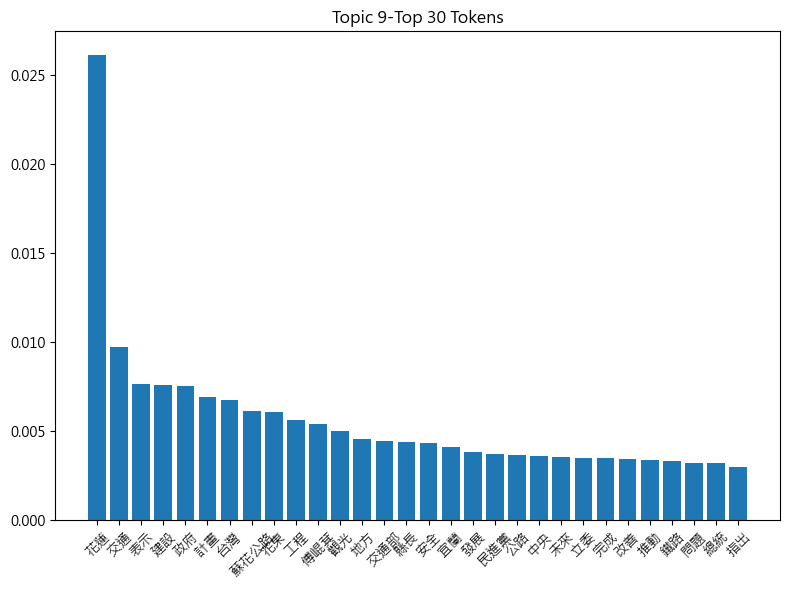

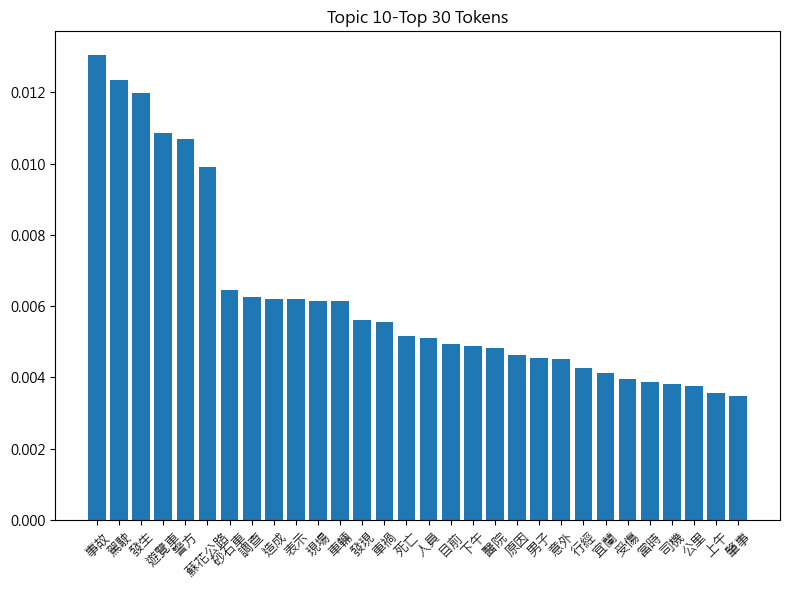

In [85]:
plot_topic_token_distri(phi_df, 30)

In [86]:
def display_topics(model, feature_names, topn=30):
    for index, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-topn-1:-1]]
        print(f"主題 {index+1}: {'、'.join(top_words)}")
display_topics(lda, vectorizer.get_feature_names_out())

主題 1: 路段、公路、封閉、停航、系統、實施、國道、公里、颱風、下午、航班、總局、壅塞、台北、預警性、取消、行駛、預計、預估、全部、交流道、表示、北上、部分、車潮、上午、航次、列車、南下、蘇花公路
主題 2: 宜蘭、台灣、表示、生活、遺址、評估、網友、進行、環境、垃圾、po、蘇花公路、真的、希望、考古、高鐵、看到、知道、時間、工作、民眾、工程、問題、野營、運動、比較、環島、發現、透過、宜蘭縣
主題 3: 台灣、臺灣、中國、國家、經濟、宜蘭、馬拉松、社會、政府、挑戰、國際、工作、跑者、防災、表示、關係、民主、蘇花公路、日本、路跑、不斷、希望、總統、釣魚台、活動、保釣、發展、第一、能夠、大陸
主題 4: 花蓮、地震、發生、目前、規模、表示、蘇花公路、落石、災情、民眾、台鐵、造成、影響、倒塌、中心、強震、地區、大樓、台灣、人員、救災、前往、災害、指出、宜蘭、飯店、時間、中央、傳出、震度
主題 5: 蘇花公路、公路、路段、通行、道路、管制、總局、交通、隧道、蘇澳、雙向、時段、搶通、下午、公路局、上午、表示、路況、花蓮、崇德、北上、車流、開放、發生、安全、坍方、時間、民眾、養護、落石
主題 6: 蘇花公路、隧道、機車、公路、安全、通車、開放、行駛、總局、公里、通行、表示、路段、蘇澳、貨車、大型、重機、行車、交通、交通部、東澳、工程、道路、速限、南澳、試辦、小時、國道、公尺、改善
主題 7: 客運、國道、優惠、路線、民眾、運輸、搭乘、疏運、蘇澳、連假、春節、宜蘭、提供、地區、期間、措施、票價、公共、公路、免費、轉運站、業者、轉乘、台鐵、公車、交通部、台灣、大眾、使用、北花
主題 8: 花蓮、景點、旅遊、體驗、蘇花公路、台灣、活動、公園、旅客、地址、遊客、這裡、飯店、台北、園區、欣賞、步道、宜蘭、路線、獨木舟、提供、民眾、位於、特色、觀光、斷崖、今年、時間、太魯閣、清水
主題 9: 花蓮、交通、表示、建設、政府、計畫、台灣、蘇花公路、花東、工程、傅崐萁、觀光、地方、交通部、縣長、安全、宜蘭、發展、民進黨、公路、中央、未來、立委、完成、改善、推動、鐵路、問題、總統、指出
主題 10: 事故、駕駛、發生、遊覽車、警方、蘇花公路、砂石車、調查、造成、表示、現場、車輛、發現、車禍、死亡、人員、目前、下午、醫院、原因、男子、意外、行經、宜蘭、受傷、當時、司機、公里、上午、肇事


C:\Users\No\AppData\Local\Temp\ipykernel_19040\1723535593.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Topic', palette='Set2')


<Axes: xlabel='Topic', ylabel='count'>

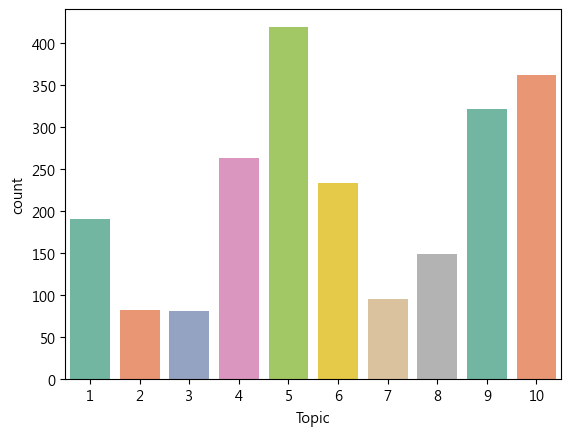

In [87]:
sns.countplot(data=data, x='Topic', palette='Set2')

In [88]:
from sklearn.manifold import TSNE

<Axes: xlabel='x', ylabel='y'>

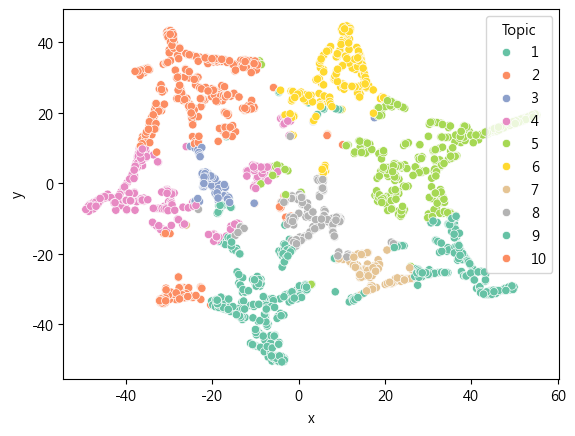

In [89]:
tsne = TSNE(n_components=2, random_state=42)
lda_tsne = tsne.fit_transform(lda_matrix)
tsne_df = pd.DataFrame(lda_tsne, columns=['x', 'y'])
tsne_df['Topic'] = data['Topic']

sns.scatterplot(data=tsne_df, x='x', y='y', hue='Topic', palette='Set2')

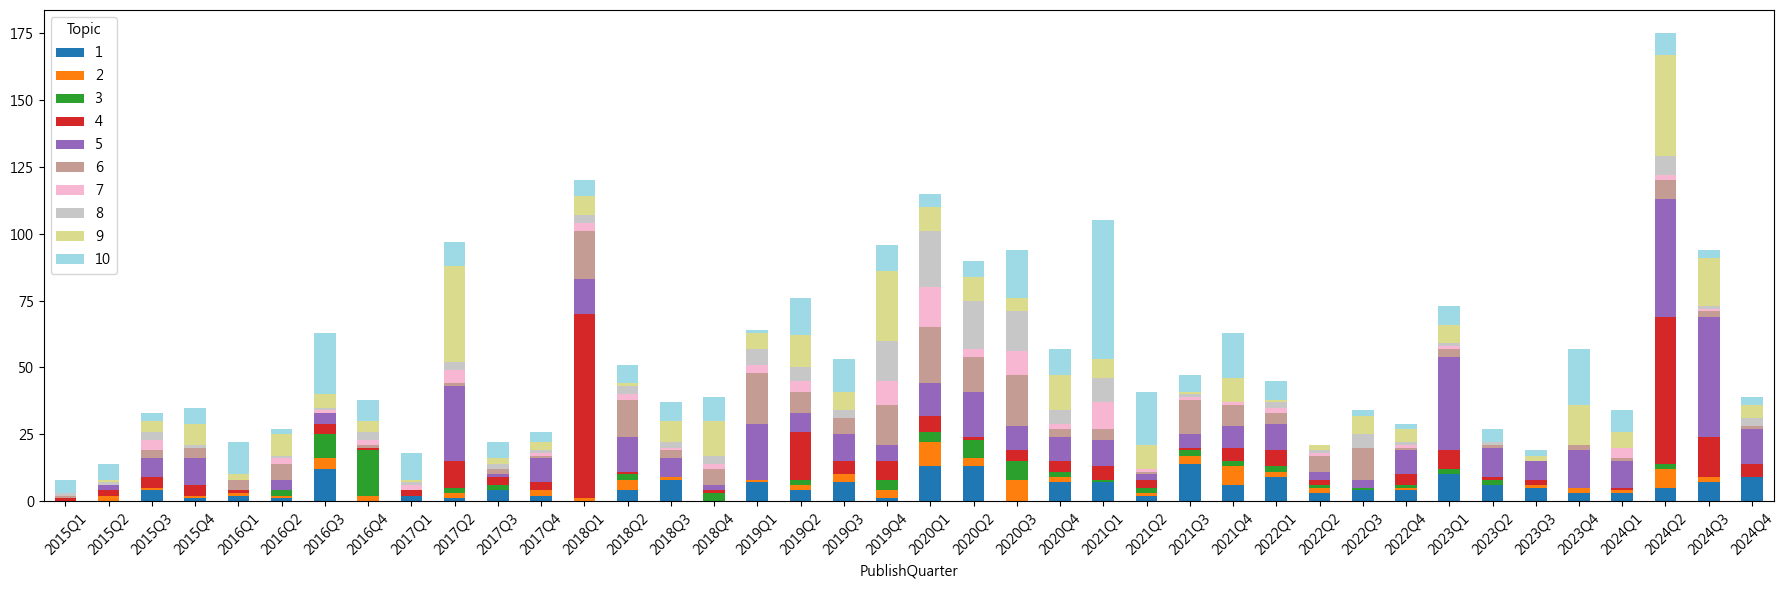

In [90]:
topic_quarter = data.groupby(['PublishQuarter', 'Topic']).size().unstack(fill_value=0)

topic_quarter.plot(kind='bar', stacked=True, colormap='tab20', figsize=(18, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

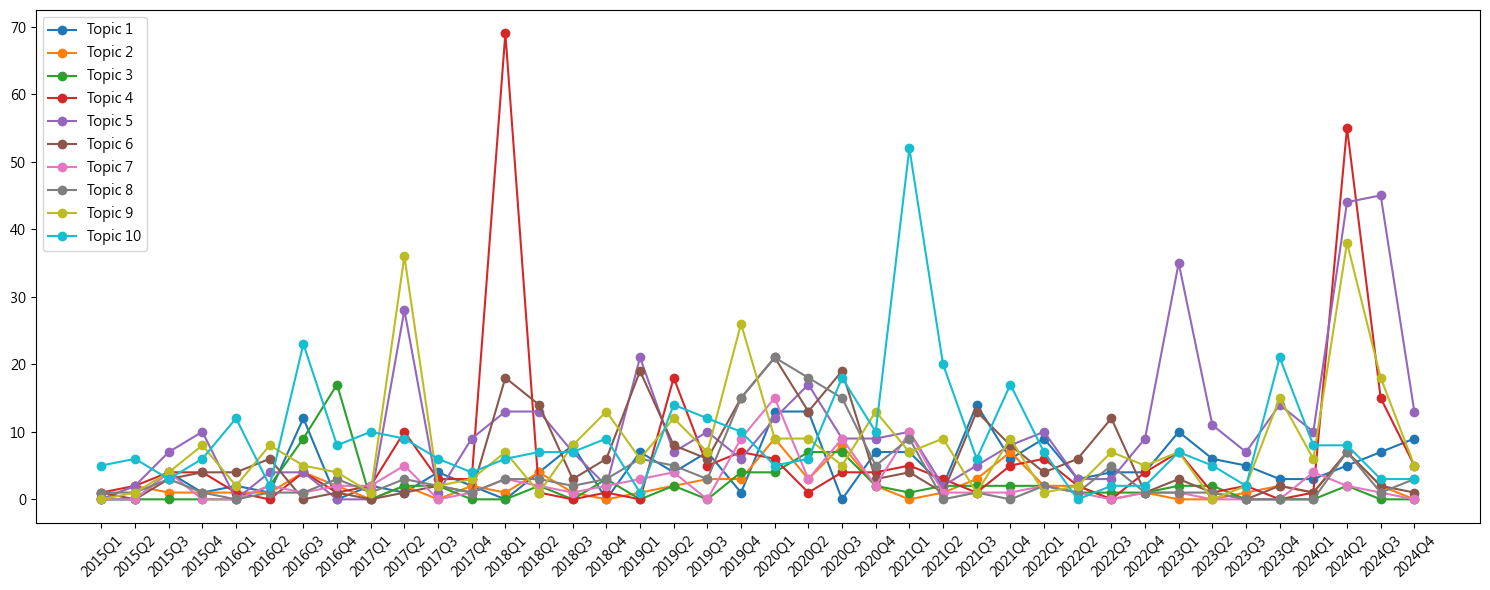

In [91]:
all_quarters = sorted(data['PublishQuarter'].unique())

plt.figure(figsize=(15, 6))
for topic in sorted(data['Topic'].unique()):
    topic_group = data[data['Topic'] == topic].groupby('PublishQuarter').size()
    topic_group = topic_group.reindex(all_quarters, fill_value=0)
    plt.plot(all_quarters, topic_group, marker='o', label=f'Topic {topic}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
# 取得所有詞彙（對應每一欄）
terms = vectorizer.get_feature_names_out()

# 建立詞頻 DataFrame：每列為一篇文章
df_count = pd.DataFrame(count_matrix.toarray(), columns=terms)

df_count.head()


,abs,ab段,ab線,ac,acc,action,adas,aed,af,afc,...,龜速車,龜速車罰,龜首,車站,路段,路線,行駛,ｄａｋａ,ｓｕｐ,ﾟe
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [93]:
n_topics = lda.n_components  # 主題數
topic_cols = [f'Topic {i}' for i in range(n_topics)]

df_lda = pd.DataFrame(lda_matrix, columns=topic_cols)

# 顯示前幾篇的主題機率
df_lda.head()


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9
0,0.149555,0.000113,0.000113,0.035335,0.000113,0.000113,0.000113,0.395690,0.153095,0.265760
1,0.000156,0.000156,0.000156,0.000156,0.000156,0.603958,0.143660,0.251289,0.000156,0.000156
2,0.000848,0.000848,0.000847,0.000847,0.992372,0.000848,0.000848,0.000847,0.000848,0.000847
3,0.000164,0.000164,0.144365,0.443456,0.028945,0.073478,0.000164,0.000164,0.308936,0.000164
4,0.000559,0.000559,0.000559,0.000559,0.000559,0.000559,0.324910,0.670620,0.000559,0.000559


In [95]:
from sklearn.feature_extraction.text import CountVectorizer

texts = data['CKIP_Tokens'].apply(lambda x: ' '.join(x)).tolist()
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

term_freq_matrix = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
term_freq_matrix

,abs,ab段,ab線,ac,acc,action,adas,aed,af,afc,...,龜速車,龜速車罰,龜首,車站,路段,路線,行駛,ｄａｋａ,ｓｕｐ,ﾟe
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2194,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2196,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [96]:
tsne2 = TSNE(n_components=2, random_state=42)
tsne2_results = tsne2.fit_transform(term_freq_matrix)
tsne2_df = pd.DataFrame(tsne2_results, columns=['x', 'y'])
tsne2_df['Topic'] = data['Topic']

<Axes: xlabel='x', ylabel='y'>

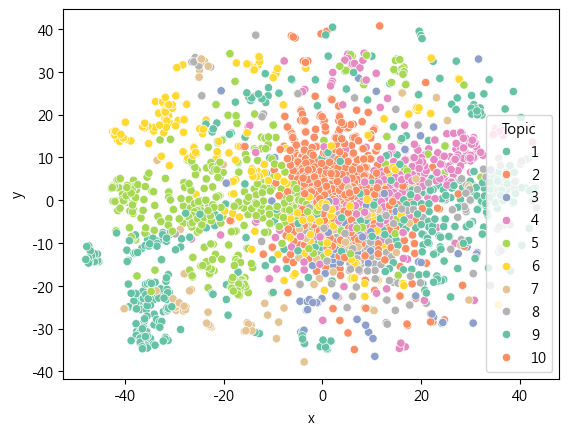

In [97]:
sns.scatterplot(data=tsne2_df, x='x', y='y', hue='Topic', palette='Set2')